In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import krswaps as krs
from itertools import product
from rdkit import Chem
from rdkit.Chem import AllChem
import time
import numpy as np
from scipy.optimize import curve_fit

Build PKS Designs (0 to 4 extension modules)

In [3]:
# Loading Module Substrates
# Limit to first 10
starters = ['Malonyl-CoA', 'Methylmalonyl-CoA', 'Hydroxymalonyl-CoA', 'Allylmalonyl-CoA', 'butmal', 'mxmal', 'cemal', 'Acetyl-CoA', 'prop', 'isobut']

# Extension Module Substrates
# Limit to malonyl-CoA and methylmalonyl-CoA (no-alpha substituent vs. alpha-substituent)
extenders = ['Malonyl-CoA', 'Methylmalonyl-CoA']

# Only type-A and type-B KRs if substrate has no-alpha substituent (i.e. malonyl-CoA)
kr_subtypes_no_alpha = ['A', 'B']

# Else:
kr_subtypes_alpha = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']

# If alpha-substituent, the ER domain redetermines its stereochemistry
er_subtypes = ['L', 'D']

NONE = 'None'
DESIGN = ['Module', 'Substrate', 'KR Type', 'DH Type', 'ER Type']

# Account for biosynthesis limitations
def kr_no_alpha(substrate):
    return kr_subtypes_no_alpha if substrate == 'Malonyl-CoA' else kr_subtypes_alpha

def dh_kr_compatibility(kr):
    if kr == 'A':
        return 'Z'
    if kr in ('B', 'B1'):
        return 'E'
    return 'None'

# Define the possible subtype-subtype options for different reductive loop architectures
def extension_module_architecture():
    for substrate in extenders:
        yield (substrate, NONE, NONE, NONE)
        for kr in kr_no_alpha(substrate):
            yield (substrate, kr, NONE, NONE)
            dh = dh_kr_compatibility(kr)
            if dh == 'None':
                continue
            yield (substrate, kr, dh, NONE)
            if dh != 'E':
                continue
            for er in er_subtypes:
                yield (substrate, kr, dh, er)

# Initialize design
def empty_design():
    return {col: [] for col in DESIGN}

def generate_designs(max_extension_modules: int) -> dict:
    extension_modules = list(extension_module_architecture())
    designs = {}
    design_id = 0
    for starter in starters:
        for n in range(max_extension_modules + 1):
            for combination in product(extension_modules, repeat=n):
                design = empty_design()
                for idx, (substrate, kr, dh, er) in enumerate([(starter, NONE, NONE, NONE)] + list(combination)):
                    design['Module'].append(idx)
                    design['Substrate'].append(substrate)
                    design['KR Type'].append(kr)
                    design['DH Type'].append(dh)
                    design['ER Type'].append(er)
                designs[design_id] = design
                design_id += 1
    return designs

no_extension_mod_dicts = generate_designs(0)
one_extension_mod_dicts = generate_designs(1)
two_extension_mod_dicts = generate_designs(2)
three_extension_mod_dicts = generate_designs(3)
four_extension_mod_dicts = generate_designs(4)

In [5]:
print("Library Sizes:")
print("0 Ext. Modules:", len(no_extension_mod_dicts))
print("1 Ext. Modules:", len(one_extension_mod_dicts))
print("2 Ext. Modules:", len(two_extension_mod_dicts))
print("3 Ext. Modules:", len(three_extension_mod_dicts))
print("4 Ext. Modules:", len(four_extension_mod_dicts))

Library Sizes:
0 Ext. Modules: 10
1 Ext. Modules: 180
2 Ext. Modules: 3070
3 Ext. Modules: 52200
4 Ext. Modules: 887410


From the generated PKS designs -> use the BCS module to forward predict their PKS products

In [6]:
def _pks_te_thiolysis(bound_product_mol: Chem.Mol) -> Chem.Mol:
    """
    TE mediated thiolysis to release the bound product from the PKS ACP domain. Leads to a terminal acid group.
    """
    Chem.SanitizeMol(bound_product_mol)
    rxn = AllChem.ReactionFromSmarts('[C:1](=[O:2])[S:3]>>[C:1](=[O:2])[O].[S:3]')
    unbound_product_mol = rxn.RunReactants((bound_product_mol,))[0][0]
    Chem.SanitizeMol(unbound_product_mol)
    return unbound_product_mol
        
def generate_pks_library(designs: dict) -> pd.DataFrame:
    """
    Parse each design dict to generate the corresponding PKS products.
    Report the PKS design and the corresponding PKS product SMILES.
    """
    entries = []
    for design in designs.values():
        library = {}
        pks_product_mol, pks_design = krs.new_pks_design(design)
        unbound_mol = _pks_te_thiolysis(pks_product_mol)
        pks_product_smi = Chem.MolToSmiles(unbound_mol, isomericSmiles=True)
        library['PKS Design'] = pks_design
        library['PKS Product'] = pks_product_smi
        entries.append(library)
    library_df = pd.DataFrame.from_dict(entries)
    return library_df

In [7]:
wall_times = []

time_0 = time.perf_counter()
zero_ext_library = generate_pks_library(no_extension_mod_dicts)
time_1 = time.perf_counter()
wall_times.append(time_1 - time_0)
print(f"Time to generate 0 extension library: {time_1 - time_0:.2E} seconds")

one_ext_library = generate_pks_library(one_extension_mod_dicts)
time_2 = time.perf_counter()
wall_times.append(time_2 - time_1)
print(f"Time to generate 1 extension library: {time_2 - time_1:.2E} seconds")

two_ext_library = generate_pks_library(two_extension_mod_dicts)
time_3 = time.perf_counter()
wall_times.append(time_3 - time_2)
print(f"Time to generate 2 extension library: {time_3 - time_2:.2E} seconds")

three_ext_library = generate_pks_library(three_extension_mod_dicts)
time_4 = time.perf_counter()
wall_times.append(time_4 - time_3)
print(f"Time to generate 3 extension library: {time_4 - time_3:.2E} seconds")

four_ext_library = generate_pks_library(four_extension_mod_dicts)
time_end = time.perf_counter()
wall_times.append(time_end - time_4)
print(f"Time to generate 4 extension library: {time_end - time_4:.2E} seconds")

Time to generate 0 extension library: 1.25E-02 seconds
Time to generate 1 extension library: 1.08E-01 seconds
Time to generate 2 extension library: 2.43E+00 seconds
Time to generate 3 extension library: 6.20E+01 seconds
Time to generate 4 extension library: 1.26E+03 seconds


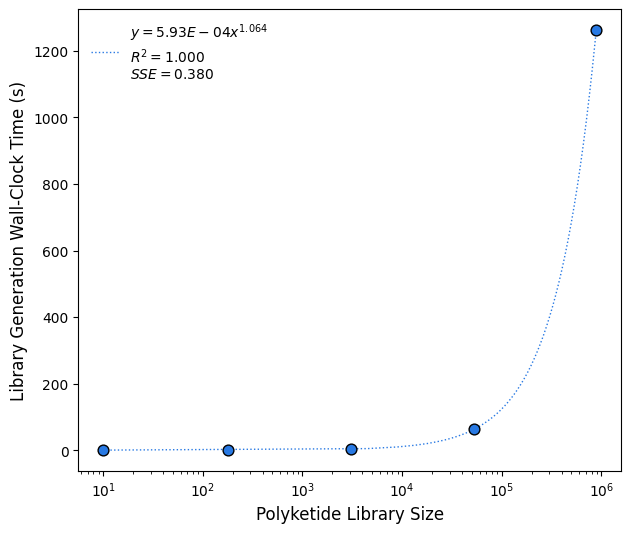

In [12]:
library_sizes = [zero_ext_library.shape[0], one_ext_library.shape[0], two_ext_library.shape[0], three_ext_library.shape[0], four_ext_library.shape[0]]

# Fit power law to library generation times
def power_law_func(x, a, b):
    return a * np.power(x, b)

def fit_power_law(x, y):
    popt, pcov = curve_fit(power_law_func, x, y, p0=(0.0005, 1))
    a, b = popt
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = power_law_func(x_fit, a, b)
    residuals = y - power_law_func(x, a, b)
    ss_res = np.sum(residuals**2)          
    ss_tot = np.sum((y - np.mean(y))**2)   
    r_squared = 1 - (ss_res / ss_tot)
    return x_fit, y_fit, r_squared, a, b, ss_res

x_fit, y_fit, r_squared, a, b, ss_res = fit_power_law(np.array(library_sizes), np.array(wall_times))

fig, ax = plt.subplots(figsize=(7, 6))
plt.scatter(library_sizes, wall_times, facecolor="#2879e3", edgecolor='black', s=60, zorder=2)
plt.plot(x_fit, y_fit, color="#2879e3", linestyle=':', linewidth=1, zorder=1, label=f'$y={a:.2E}x^{{{b:.3f}}}$\n$R^2 = {r_squared:.3f}$\n$SSE = {ss_res:.3f}$')
plt.xscale('log')
plt.legend(fontsize=10, loc='upper left', frameon=False)
plt.xlabel('Polyketide Library Size', fontsize=12)
plt.ylabel('Library Generation Wall-Clock Time (s)', fontsize=12)
plt.savefig('library_generation_time_scaling.svg', bbox_inches='tight', format='svg')
plt.show()